# Regression
## Sales price prediction using Ames Housing Dataset

In [307]:
import pandas as pd
import numpy as np

In [308]:
df = pd.read_csv('AmesHousing.txt', sep='\t')
# df = pd.read_csv('https://jse.amstat.org/v19n3/decock/AmesHousing.txt', sep='\t')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [309]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [310]:
# select features for building the model
df = df[['Overall Qual', 'Overall Cond', 'Total Bsmt SF', 'Gr Liv Area', 'Central Air', 'SalePrice']]

In [311]:
df.dropna(axis=0, inplace=True)
df.isna().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Gr Liv Area      0
Central Air      0
SalePrice        0
dtype: int64

In [312]:
df['Central Air'] = df['Central Air'].map({'Y': 1, 'N': 0})
df
# df[df['Central Air'] == 0]

,Overall Qual,Overall Cond,Total Bsmt SF,Gr Liv Area,Central Air,SalePrice
0,6,5,1080.0,1656,1,215000
1,5,6,882.0,896,1,105000
2,6,6,1329.0,1329,1,172000
3,7,5,2110.0,2110,1,244000
4,5,5,928.0,1629,1,189900
...,...,...,...,...,...,...
2925,6,6,1003.0,1003,1,142500
2926,5,5,864.0,902,1,131000
2927,5,5,912.0,970,1,132000
2928,5,5,1389.0,1389,1,170000


# EDA (Exploratory Data Analysis)
- 통계적인 수치들을 가지고 여러 그림들을 그려보는 것.

In [313]:
import matplotlib.pyplot as plt
import seaborn as sns

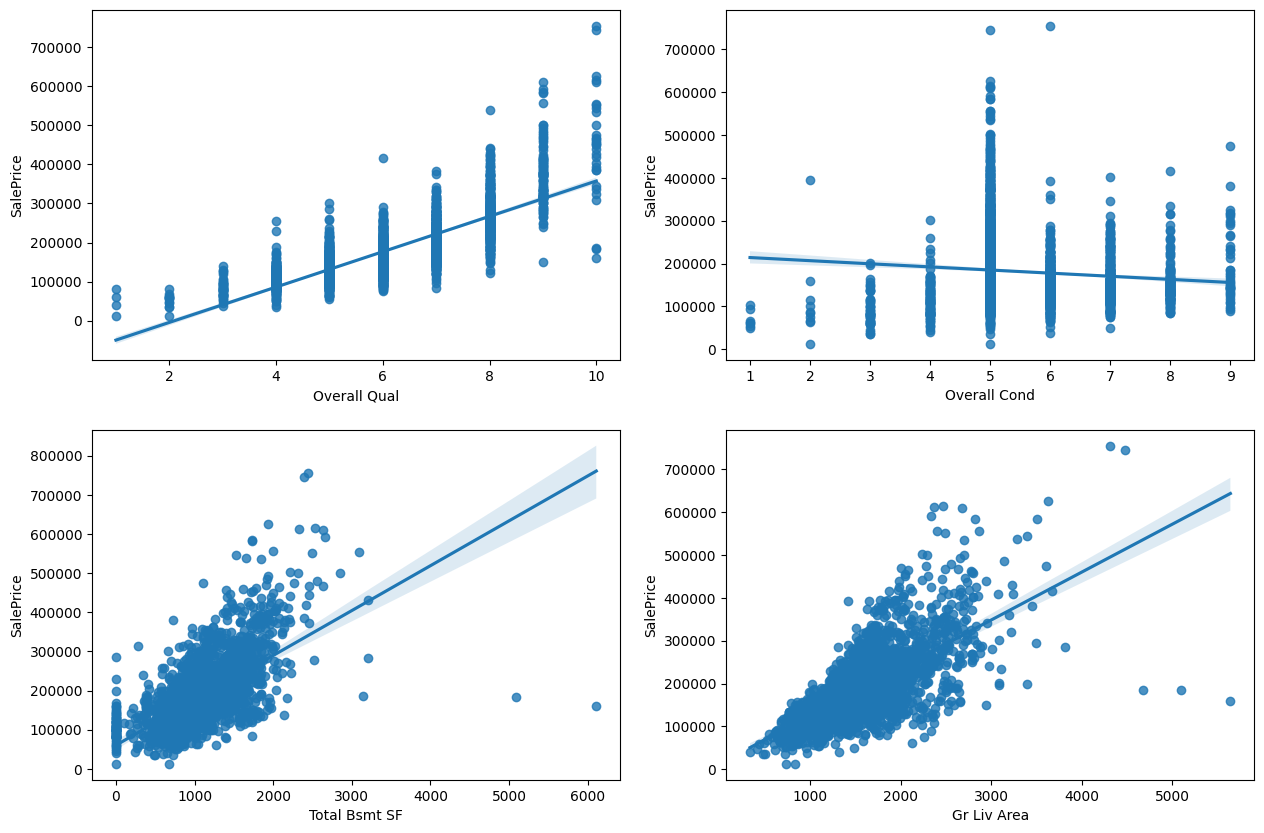

In [314]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.regplot(ax=axes[0, 0], data=df, x='Overall Qual', y='SalePrice')
sns.regplot(ax=axes[0, 1], data=df, x='Overall Cond', y='SalePrice')
sns.regplot(ax=axes[1, 0], data=df, x='Total Bsmt SF', y='SalePrice')
sns.regplot(ax=axes[1, 1], data=df, x='Gr Liv Area', y='SalePrice')
plt.show()

# SalePrice는 Overal Qual, Gr Liv Area와 연관성이 높다.

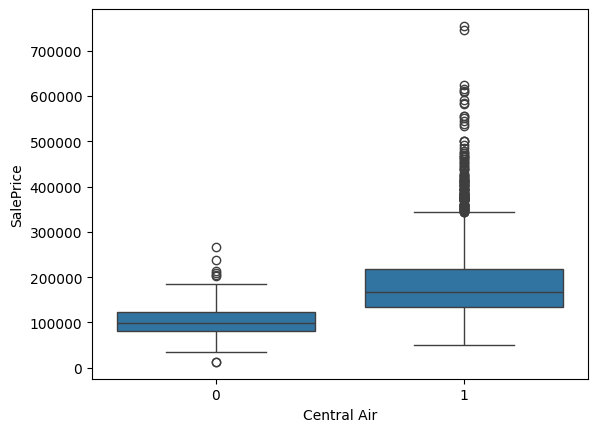

In [315]:
sns.boxplot(data=df, x='Central Air', y='SalePrice')
plt.show()
# 가운데 선 - Q2 median
# 박스 아래쪽 선 - Q1 25%
# 박스 위쪽 선 - Q3 75%
# IQR = Q3 - Q1
# outliers = Q3 + 1.5 * IQR 보다 큰 값, Q1 - 1.5 * IQR 보다 작은 값.
# 여기서 볼 수 있는 것 -> 에어컨 있는 집이 확실히 가격이 비싸다.

## Regression with Scikit-learn
- 모델을 만드는 이유: 예측을 하기 위함.

- Dimensionality reduction
  - 어떤 feature를 쓸지 정해줌.

In [316]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [317]:
# data (ndarray)
X = df['Gr Liv Area'].values # input features
# X = df[['Gr Liv Area', 'Overall Qual']].values # feature를 여러 개 쓰는 경우가 더 많다.
Y = df['SalePrice'].values   # targets/labels

# scikit-learn은 axis가 2개이길 원한다.
if X.ndim == 1:
    X = X.reshape(-1, 1)

Y = Y.reshape(-1, 1)

# 값들 간의 차이가 크면 문제가 있다?
# 큰 값들의 영향력이 너무 커진다. 작은 값은 묻힌다.
print(X.shape, Y.shape)
print(X) # 값들 하나하나를 example/sample이라고 한다.
print()
print(Y) # 각 넓이를 가지는 집에 해당하는 가격.

(2929, 1) (2929, 1)
[[1656]
 [ 896]
 [1329]
 ...
 [ 970]
 [1389]
 [2000]]

[[215000]
 [105000]
 [172000]
 ...
 [132000]
 [170000]
 [188000]]


In [318]:
# Standardization/Normalization
# StandardScaler -> 데이터를 normally distributed하게 바꿔준다.
sc_X = StandardScaler()
sc_Y = StandardScaler()

X_std = sc_X.fit_transform(X)
Y_std = sc_Y.fit_transform(Y)

# normalized data
# 데이터를 표준정규분포로 바꿔버림.
# mean=0, variance=1
print(X_std)
print(Y_std)

[[ 0.30887979]
 [-1.19492198]
 [-0.33815071]
 ...
 [-1.04849917]
 [-0.21942951]
 [ 0.98954796]]
[[ 0.42783926]
 [-0.94949293]
 [-0.11057241]
 ...
 [-0.61142048]
 [-0.13561481]
 [ 0.08976682]]


In [319]:
# Split data to train/test
# 학습에 썼던 데이터로 다시 테스트하면 컨닝페이퍼를 주는 것과 같다.
# 새로운 데이터를 예측하는 것이 목표, 테스트 데이터를 미리 분리해야 한다.
# Learning the parameters of a prediction function and testing it on the same data is a methodological mistake:
#   a model that would just repeat the labels of the samples that it has just seen would have a perfect score but would fail to predict anything useful on yet-unseen data.
# This situation is called overfitting.
# To avoid it, it is common practice when performing a (supervised) machine learning experiment to hold out part of the available data as a test set X_test, y_test.

In [320]:
# 데이터는 랜덤하게 잘라온다.
X_train, X_test, Y_train, Y_test = train_test_split(X_std, Y_std, test_size=0.3, ) # test data = 30%, train_data = 70% (train data가 많으면 좋기 때문에 5:5는 좋지 않다. 보통 3:7..)
print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

(2050, 1) (2050, 1)
(879, 1) (879, 1)


In [321]:
# Model Selection

from sklearn import svm # support vector machine
from my_linear_model import MySimpleLinearRegression

# model = LinearRegression()
# model = svm.SVR(degree=5) # svm regression, non-linear

model = MySimpleLinearRegression()

In [322]:
# Model fitting / Training
# X feature 2개로 늘렸다.
model.fit(X_train, Y_train)

In [323]:
# y=coef*x + intercept
if hasattr(model, 'coef_'):
    print(f'coef: {model.coef_}') # coef 2개가 생김. 각각 Gr Liv Area, Overal Qual
    print(f'intercept: {model.intercept_}')

coef: 0.7036632228910035
intercept: -0.008562005657462058


In [324]:
Y_pred = model.predict(X_test)

In [325]:
# evaluation
for y, y_pred in zip(Y_test, Y_pred):
    print(y, y_pred) # 왼쪽: 테스트 데이터 정답, 오른쪽: 예측 데이터

[-0.64961015] [-0.39130843]
[0.11480922] [-0.47345584]
[-1.14983216] [-0.77698355]
[0.50296647] [0.0862604]
[-0.98705653] [-0.37320815]
[0.64069969] [0.15309219]
[-0.55507507] [-0.11701963]
[-0.7804567] [-0.7936915]
[0.08976682] [0.21157]
[1.22919617] [0.56800621]
[0.09853166] [0.21435466]
[-0.36099645] [-0.529149]
[-1.4941652] [-1.41188555]
[-0.52377207] [-0.35650021]
[0.35897265] [0.06676779]
[-0.0145974] [-0.01398729]
[-1.01835954] [-0.82710739]
[-0.57385688] [-0.73242902]
[-0.68654769] [0.317387]
[-0.3052771] [-0.80761479]
[-0.81113365] [-0.89393918]
[-0.11057241] [-0.24650622]
[-0.65524469] [-0.51940269]
[4.43462382] [1.6595921]
[-0.67402649] [-0.55560325]
[0.61565729] [1.08873724]
[0.21372671] [0.59724512]
[0.59061489] [0.82280241]
[2.79434639] [0.71559308]
[-0.42360245] [-0.71015176]
[0.61565729] [1.09291422]
[-0.34221464] [0.07372944]
[-0.47368726] [-0.40662405]
[-0.13561481] [-0.16296648]
[-0.33094556] [0.18511575]
[-0.24204503] [0.39257276]
[-0.55507507] [-0.634966]
[-0.29212

In [326]:
from sklearn.metrics import r2_score
# RSE = 
# R^2 = 1 - RSE

# feature를 2개 쓰니까 정확도가 올라갔다.
score = r2_score(Y_test, Y_pred)
print(f'R2 : {score}') # 보통 R^2 = 0.8 넘어가면 굉장히 정확하다고 한다.
# input feature를 늘리고, 데이터에 맞는 모델을 사용하면 정확도가 올라간다.

R2 : 0.47771343411638145


In [327]:
# help(sc_Y.inverse_transform)
print(Y_pred.shape)

(879, 1)


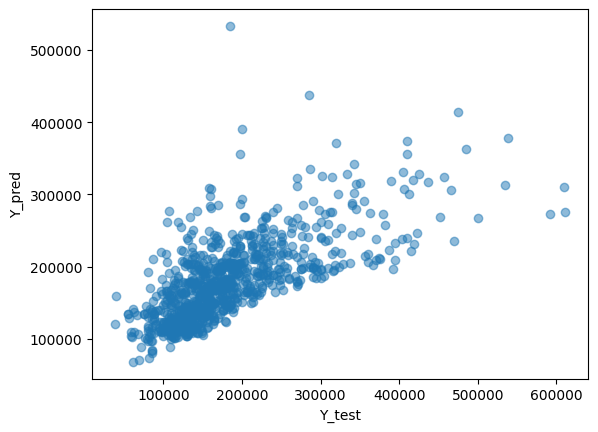

In [328]:
# plot
fig, ax = plt.subplots()
ax.scatter(sc_Y.inverse_transform(Y_test), sc_Y.inverse_transform(Y_pred.reshape(-1,1)), alpha=0.5)
ax.set(xlabel='Y_test', ylabel='Y_pred')
plt.show()
# 꽤나 선형적으로 잘 맞추고 있다.